<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/ML/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [3]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [4]:
from sklearn.model_selection import train_test_split

X = df[['tenure', 'monthly', 'support', 'age']] #features
y = df['churn'] #target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Studying print: ", X_train.shape[0], "clients")
print("Testing print: ", X_test.shape[0], "clients")

Studying print:  960 clients
Testing print:  240 clients


In [5]:
df.columns

Index(['tenure', 'monthly', 'support', 'age', 'churn'], dtype='object')

In [6]:
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE

)

model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)



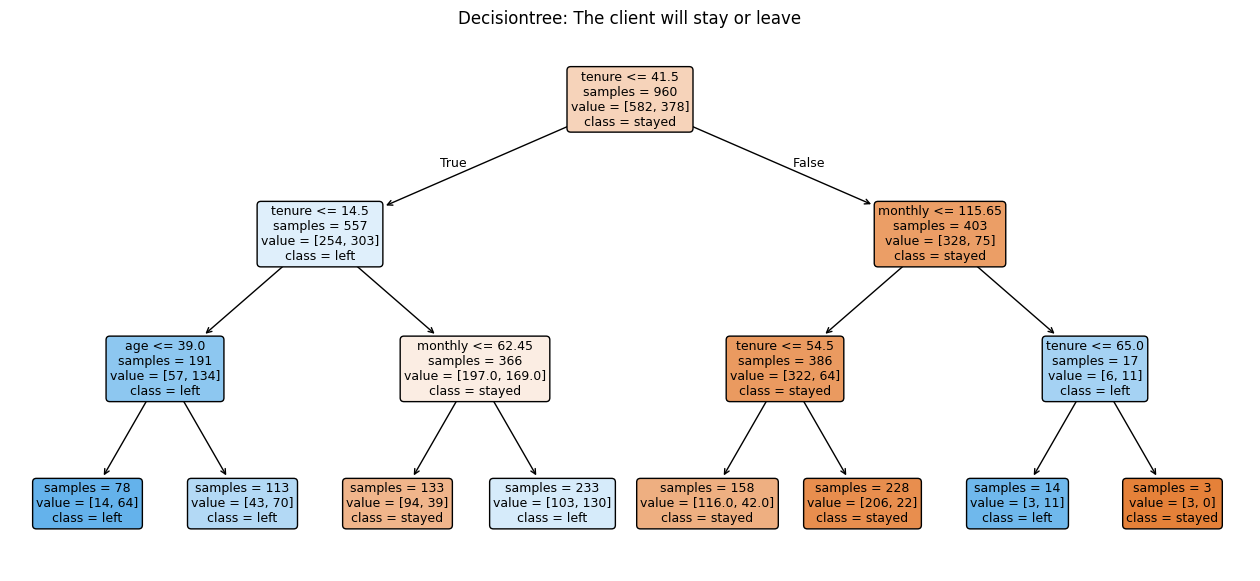

In [7]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16,7))
plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=['stayed', 'left'],
    filled=True, rounded=True, fontsize=9, impurity=False
)

plt.title('Decisiontree: The client will stay or leave')
plt.show()

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy = {acc:.2%}')

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=['Really stayed', 'Really left'],
    columns=['Predicted stayed', 'Predicted left']
)


display(df_cm)
print('\nDetailed report:')
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Accuracy = 59.17%


,Predicted stayed,Predicted left
Really stayed,85,61
Really left,37,57



Detailed report:
              precision    recall  f1-score   support

      Stayed       0.70      0.58      0.63       146
        Left       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240



# Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_forest.fit(X_train, y_train)
y_pred_rf = model_forest.predict(X_test)

print(f'One tree: accuracy = {accuracy_score(y_test, y_pred):.2%}')
print(f'All forest: accuracy = {accuracy_score(y_test, y_pred_rf):.2%}')

One tree: accuracy = 59.17%
All forest: accuracy = 64.58%


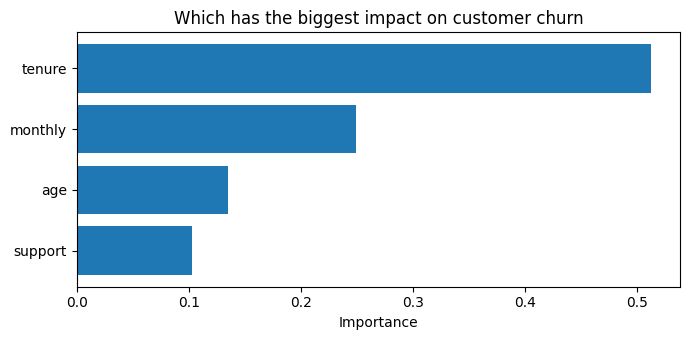

In [10]:
importances = pd.DataFrame({
    'features': X.columns,
    'importances': model_forest.feature_importances_.round(3)

}).sort_values('importances', ascending=True)

plt.figure(figsize=(7, 3.5))
plt.barh(importances['features'], importances['importances'] )

plt.xlabel('Importance')
plt.title('Which has the biggest impact on customer churn')
plt.tight_layout()
plt.show()




In [11]:
X.columns


Index(['tenure', 'monthly', 'support', 'age'], dtype='object')

In [16]:
new_client = pd.DataFrame([{
    'tenure': 3,
    'monthly': 95,
    'support': 5,
    'age': 25
}])
new_client

,tenure,monthly,support,age
0,3,95,5,25


In [20]:
print(f'Uncertainty % of churn: {model_forest.predict_proba(new_client)[0, 1]:.2%}')
print(f"Decision: {"LEAVE" if model_forest.predict(new_client)[0] else "STAY"}")

print ('\n-----------------')
print(f'Probability % of churn: {accuracy_score(y_test, y_pred_rf):.2%}')

Uncertainty % of churn: 88.66%
Decision: LEAVE

-----------------
Probability % of churn: 64.58%
